In [11]:
import torch

pattern = "petals"
perturbed_data = torch.load(f"expanded_datasets/{pattern}_attack_N1150_train.pt", weights_only=False)
original_data = torch.load(f"all_patterns/{pattern}/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPattern{pattern}.pt", weights_only=False)

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import Tuple

def plot_pert_and_diff_side_by_side(
    pert_y: torch.Tensor,          # shape: (N, H, W, T)
    orig_y: torch.Tensor,          # shape: (N, H, W, T)
    rows: int = 5,
    cols: int = 5,                 # 每行 cols 张 perturbed + cols 张 diff => 列总数 = 2*cols
    cmap_pert: str = "viridis",
    cmap_diff: str = "coolwarm",
    origin: str = "lower"
) -> plt.Figure:
    """
    每行前 cols 张图为 perturbed frames，后 cols 张图为差值 diff（pert − orig），共 rows 行。
    空白帧不显示子图。
    """

    # 基本检查
    if pert_y.ndim != 4 or orig_y.ndim != 4:
        raise ValueError(f"expect (N,H,W,T), got {tuple(pert_y.shape)} and {tuple(orig_y.shape)}")

    Np, H, W, Tp = pert_y.shape
    No, Ho, Wo, To = orig_y.shape
    if (H, W) != (Ho, Wo):
        raise ValueError(f"spatial size mismatch: pert {(H,W)} vs orig {(Ho,Wo)}")

    T = min(Tp, To)

    max_frames_per_side = rows * cols
    num_frames = min(T, max_frames_per_side)

    # 提取样本并转 numpy
    p = pert_y.mean(axis=0).detach().cpu().numpy()   # (H, W, T)
    o = orig_y.mean(axis=0).detach().cpu().numpy()   # (H, W, T)
    diff = p[..., :T] - o[..., :T]                       # (H, W, T)

    total_cols = cols * 2
    fig, axes = plt.subplots(rows, total_cols, figsize=(total_cols * 1.5, rows * 1.5), constrained_layout=True)
    axes = np.asarray(axes)

    # 填充
    for r in range(rows):
        for c in range(cols):
            frame_idx = r * cols + c
            # 如果帧编号超出 num_frames，就隐藏这2个子图
            if frame_idx >= num_frames:
                axes[r, c].set_visible(False)
                axes[r, cols + c].set_visible(False)
            else:
                # 左边 perturbed
                ax_p = axes[r, c]
                img_p = p[..., frame_idx]
                ax_p.imshow(img_p, origin=origin, cmap=cmap_pert)
                ax_p.set_title(f"pert t={frame_idx}", fontsize=9)
                ax_p.axis("off")

                # 右边 diff
                ax_d = axes[r, cols + c]
                img_d = diff[..., frame_idx]
                ax_d.imshow(img_d, origin=origin, cmap=cmap_diff)
                ax_d.set_title(f"diff t={frame_idx}", fontsize=9)
                ax_d.axis("off")
    fig.suptitle(f"pattern={pattern} average over N=1150")
    return fig

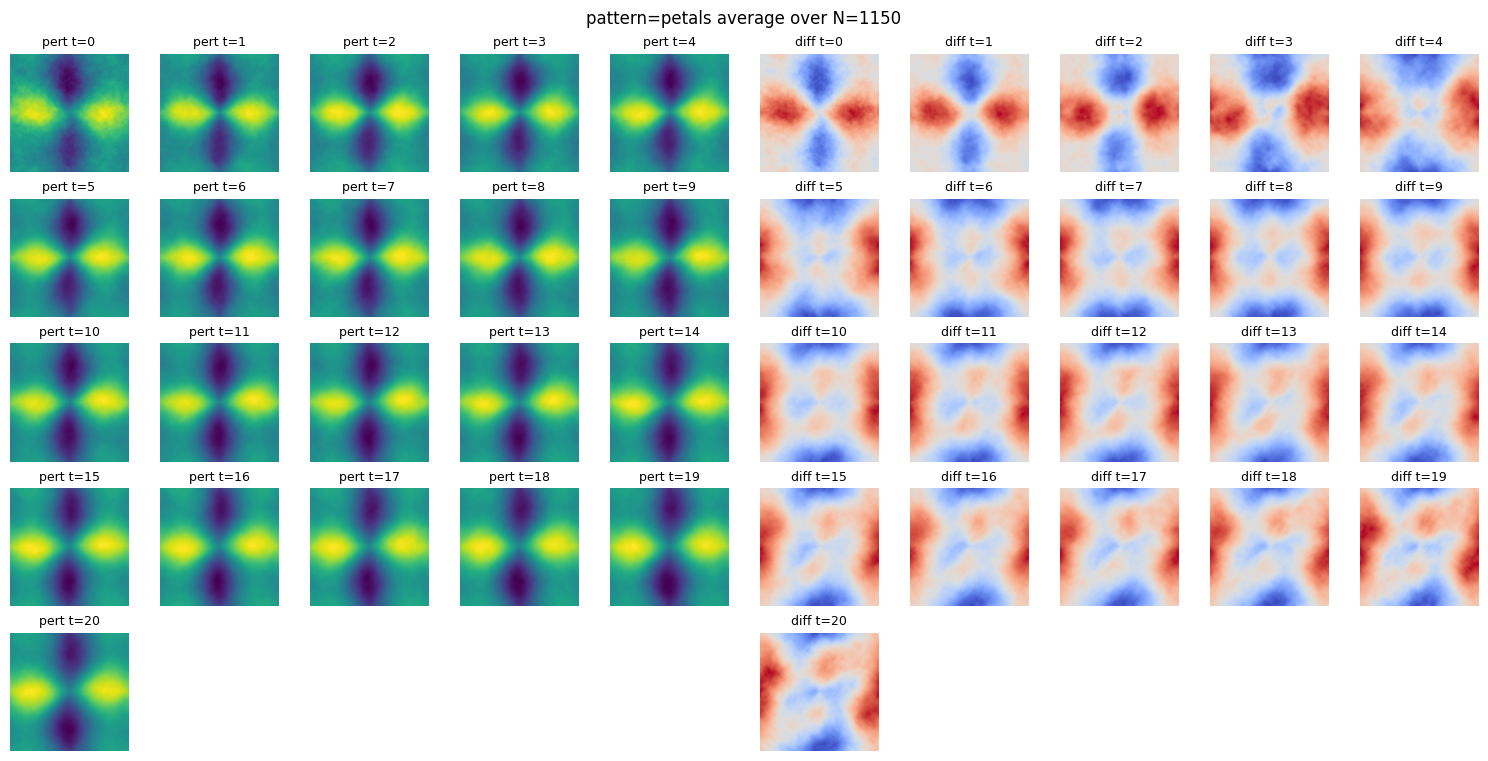

In [13]:

fig = plot_pert_and_diff_side_by_side(
    pert_y = perturbed_data["y"],
    orig_y = original_data["y"],
    rows = 5,
    cols = 5,
    cmap_pert = "viridis",
    cmap_diff = "coolwarm",
    origin = "lower"
)
plt.show()

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import Tuple

def plot_pert_and_diff_side_by_side_idx(
    pert_y: torch.Tensor,          # shape: (N, H, W, T)
    orig_y: torch.Tensor,          # shape: (N, H, W, T)
    sample_idx: int = 0,           # 第几个样本
    rows: int = 5,
    cols: int = 5,                 # 每行 cols 张 perturbed + cols 张 diff => 列总数 = 2*cols
    cmap_pert: str = "viridis",
    cmap_diff: str = "coolwarm",
    origin: str = "lower"
) -> plt.Figure:
    """
    每行前 cols 张图为 perturbed frames，后 cols 张图为差值 diff（pert − orig），共 rows 行。
    空白帧不显示子图。
    """

    # 基本检查
    if pert_y.ndim != 4 or orig_y.ndim != 4:
        raise ValueError(f"expect (N,H,W,T), got {tuple(pert_y.shape)} and {tuple(orig_y.shape)}")
    if sample_idx < 0 or sample_idx >= min(pert_y.shape[0], orig_y.shape[0]):
        raise IndexError(f"sample_idx {sample_idx} out of range")

    Np, H, W, Tp = pert_y.shape
    No, Ho, Wo, To = orig_y.shape
    if (H, W) != (Ho, Wo):
        raise ValueError(f"spatial size mismatch: pert {(H,W)} vs orig {(Ho,Wo)}")

    T = min(Tp, To)

    max_frames_per_side = rows * cols
    num_frames = min(T, max_frames_per_side)

    # 提取样本并转 numpy
    p = pert_y[sample_idx, ...].detach().cpu().numpy()   # (H, W, T)
    o = orig_y[sample_idx, ...].detach().cpu().numpy()   # (H, W, T)
    diff = p[..., :T] - o[..., :T]                       # (H, W, T)

    total_cols = cols * 2
    fig, axes = plt.subplots(rows, total_cols, figsize=(total_cols * 1.5, rows * 1.5), constrained_layout=True)
    axes = np.asarray(axes)

    # 填充
    for r in range(rows):
        for c in range(cols):
            frame_idx = r * cols + c
            # 如果帧编号超出 num_frames，就隐藏这2个子图
            if frame_idx >= num_frames:
                axes[r, c].set_visible(False)
                axes[r, cols + c].set_visible(False)
            else:
                # 左边 perturbed
                ax_p = axes[r, c]
                img_p = p[..., frame_idx]
                ax_p.imshow(img_p, origin=origin, cmap=cmap_pert)
                ax_p.set_title(f"pert t={frame_idx}", fontsize=9)
                ax_p.axis("off")

                # 右边 diff
                ax_d = axes[r, cols + c]
                img_d = diff[..., frame_idx]
                ax_d.imshow(img_d, origin=origin, cmap=cmap_diff)
                ax_d.set_title(f"diff t={frame_idx}", fontsize=9)
                ax_d.axis("off")
    fig.suptitle(f"pattern={pattern} index={sample_idx}")
    return fig

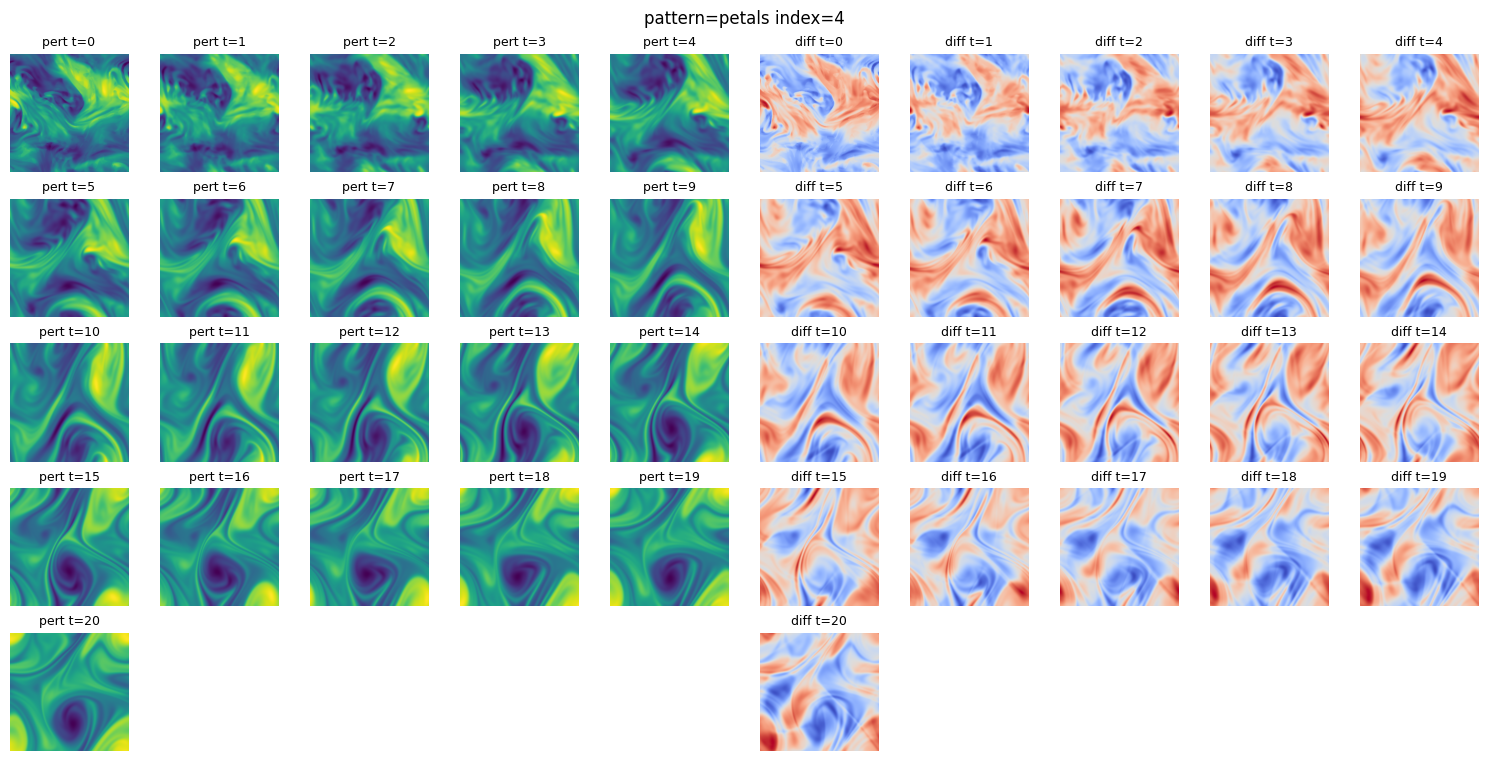

In [18]:

fig = plot_pert_and_diff_side_by_side_idx(
    pert_y = perturbed_data["y"],
    orig_y = original_data["y"],
    sample_idx = 4,
    rows = 5,
    cols = 5,
    cmap_pert = "viridis",
    cmap_diff = "coolwarm",
    origin = "lower"
)
plt.show()